In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
def audit_qualite(df):
    print("Forme : ")
    print(df.shape)
    print("\n Aperçu dataset : ")
    print(df.head())
    print("\n Infos dataset : ")
    print(df.info())
    print("\n Valeurs nulles")
    print(df.isnull().sum())
 
    print("\n Doublons :", df.duplicated().sum())
    
    print("Répartition de no-show")
    counts = df["No-show"].value_counts()
    percentages = df["No-show"].value_counts(normalize=True) * 100
    repartition = pd.DataFrame({
        "Effectif": counts,
        "Pourcentage (%)": percentages.round(2)
        })

    print(repartition)

def nettoyage(df, columns):
    df_clean = df.copy()
    df_clean = df_clean.drop(
        columns=columns
    )
    df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"])
    df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"])
 
    df_clean["waiting_days"] = (
        df_clean["AppointmentDay"] - df_clean["ScheduledDay"]
    ).dt.days

    df_clean = df_clean.drop(columns=["ScheduledDay", "AppointmentDay", 'Neighbourhood'])

    df_clean["No-show"] = df_clean["No-show"].map({
        "No": 0,
        "Yes": 1
    })
    df_clean["Gender"] = df_clean["Gender"].map({
        "F": 0,
        "M": 1
    })

    return df_clean


def split_train_val_test(df_clean, cible):
    test_size=0.2
    val_size=0.2
    random_state=42

    y = df_clean[cible]
    X = df_clean.drop(columns=[cible])
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    val_ratio_adjusted = val_size / (1 - test_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_ratio_adjusted,
        random_state=random_state,
        stratify=y_train_val
    )

    print(
        f"Train : {X_train.shape} | "
        f"Val : {X_val.shape} | "
        f"Test : {X_test.shape}"
    )

    print("\nDistribution cible (en %) :")
    for name, y_part in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(
            f"{name}:\n{(y_part.value_counts(normalize=True) * 100).round(2)}\n"
        )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


1.Chargement

2.Audit
Forme : 
(110527, 14)

 Aperçu dataset : 
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0       

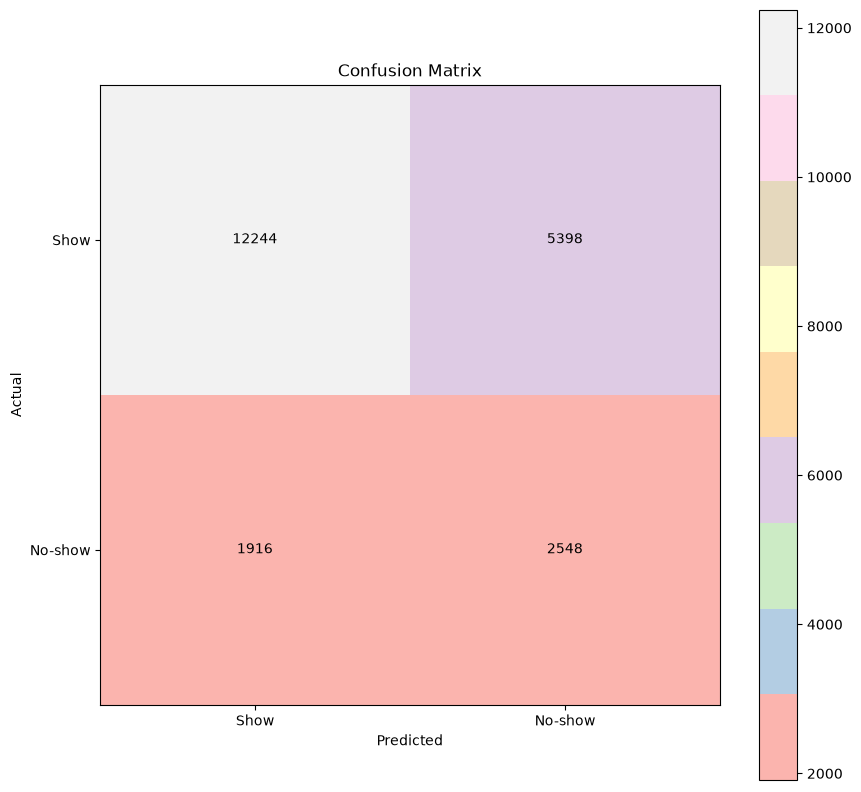

In [4]:
print("\n1.Chargement")
df_medical = pd.read_csv("KaggleV2-May-2016.csv")
colonnes_inutiles = ["PatientId", "AppointmentID"]
print("\n2.Audit")
audit_qualite(df_medical)
print("\n3.Nettoyage des données")

df_medical_clean = nettoyage(df_medical, colonnes_inutiles)

print(df_medical_clean.head())
print(df_medical_clean.info())

print("\n4. Split")
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(df_medical_clean, 'No-show')

print("\n 5. 1er algo entrainé")
modele = make_pipeline(StandardScaler(), 
                       LogisticRegression(max_iter=5000, class_weight="balanced"))
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test) 

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")

print("=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=["Show", "No-show"]))

print("=== Confusion matrix ===")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,10))
plt.imshow(cm, cmap="Pastel1")
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Show", "No-show"]

plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()